# Phase 3: Production ML Pipeline

This notebook demonstrates the final, production-ready machine learning pipeline. 

During the transition from initial exploration to production, several critical data leakage issues were identified (e.g., target variables hiding inside `order_item_total` and `order_profit_per_order`). These were removed, and the entire preprocessing logic was centralized to eliminate train-serve skew.

This notebook imports directly from our `src/` modules to ensure 100% consistency with the Streamlit app and FastAPI service.

In [1]:
import sys
import os
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# Add src to path
sys.path.insert(0, os.path.abspath("../src"))
from config import DATA_PATH, MODEL_PATH, COLUMNS_PATH
from preprocess import preprocess
from evaluate import evaluate

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Evaluate Production Model
We will run the centralized evaluation script, which loads the held-out test set, applies our strict preprocessing, and computes the honest R2 and RMSE.

In [2]:
metrics = evaluate()

  Supply Chain Model — Evaluation Report


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:42:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)



📂 Model loaded from: c:\Users\HP\supply-chain-analytics-capstone\artifacts\model.pkl

────────────────────────────────────────
  📈 TEST SET METRICS (log-scale)
────────────────────────────────────────
  R²   : 0.6886
  RMSE : 0.3989
  MAE  : 0.2728

  📈 TEST SET METRICS (real dollars)
────────────────────────────────────────
  RMSE : $60.63
  MAE  : $39.76

  📋 Saved metrics (from training):
     R²   : 0.6886
     RMSE : 0.3989

  Test samples: 8330
  Features: 27


## 2. Model Explainability (SHAP)
Let's interpret the XGBoost model using SHAP to understand which features drive our predictions.

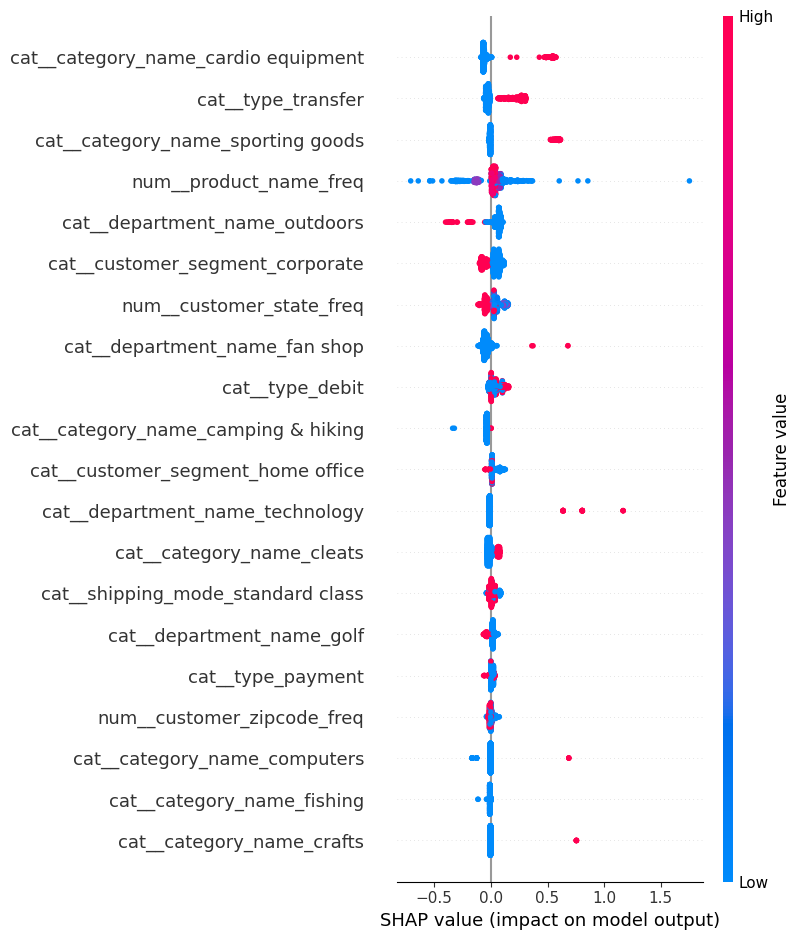

In [3]:
# Load model and data
model = joblib.load(MODEL_PATH)
columns = joblib.load(COLUMNS_PATH)
df = pd.read_csv(DATA_PATH, encoding="latin1")
df_processed = preprocess(df)

# Align columns
X = df_processed.drop(columns=["sales_log"])
X = X.reindex(columns=columns, fill_value=0)

# Extract XGBoost and Preprocessor
preprocessor = model.named_steps["preprocessor"]
xgb_model = model.named_steps["model"]

# Transform data for SHAP
X_transformed = preprocessor.transform(X)

# Calculate SHAP values for a sample of the data
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_transformed[:1000])

# Plot feature importance
feature_names = preprocessor.get_feature_names_out()
shap.summary_plot(shap_values, X_transformed[:1000], feature_names=feature_names)